---
## **[실습 프로젝트]**

이 실습에서는 옵션 2와 옵션 3의 멀티모달 RAG 시스템을 비교하고, 실제 증권사 분석보고서 질의응답 시스템을 구축합니다.

### **과제: 옵션 2와 옵션 3 비교 분석**

다음 질문들로 두 옵션을 테스트하고 결과를 비교하세요:

1. "삼성전기의 2024년 실적 전망을 그래프와 함께 설명해주세요."
2. "셀트리온의 주요 제품 매출 비중을 테이블로 보여주세요."
3. "LG전자의 분기별 영업이익률 추이는 어떻게 되나요?"

**비교 항목:**
- 답변 품질 (정확도, 상세함)
- 이미지/테이블 활용도
- 응답 시간
- API 비용 (토큰 사용량)

```python
# 옵션 2 결과
option2_result = ...

# 옵션 3 결과
option3_result = ...

# 비교 분석 코드 작성
```

### **제출 가이드**

1. 각 과제별로 실행 결과 캡처
2. 옵션 2와 옵션 3의 장단점 분석 (200자 이내)
3. 실전 시나리오 구현 코드와 테스트 결과

**평가 기준:**
- 코드 완성도 (40%)
- 실험 결과 분석 (30%)
- 창의성 및 실용성 (30%)


In [7]:
from dotenv import load_dotenv
load_dotenv()

import os
from glob import glob

from pprint import pprint
import json

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

from langfuse.langchain import CallbackHandler

# 콜백 핸들러 생성
langfuse_handler = CallbackHandler()

In [8]:
import base64
import io
from io import BytesIO

import numpy as np
from PIL import Image
from IPython.display import HTML, display
from langchain_core.documents import Document

import pickle
from langchain_core.stores import InMemoryStore


def is_base64(s):
    """문자열이 Base64로 인코딩되었는지 확인합니다"""
    try:
        return base64.b64encode(base64.b64decode(s)) == s.encode()
    except Exception:
        return False


def split_image_text_types(docs):
    """numpy 배열 이미지와 텍스트를 분리합니다"""
    images = []
    text = []
    for doc in docs:
        if isinstance(doc, str):
            pass
        elif isinstance(doc, Document):
            doc = doc.page_content  # 문서 내용 추출
        else:
            doc = doc.text # 문서 내용 추출

        if is_base64(doc):
            images.append(doc)  # base64로 인코딩된 문자열
        else:
            text.append(doc)
    return {"images": images, "texts": text}


def plt_img_base64(img_base64):
    """
    Base64로 인코딩된 이미지를 주피터 노트북에 표시
    
    매개변수:
    img_base64 (str): Base64로 인코딩된 이미지 문자열
    """
    # Base64 문자열을 소스로 하는 HTML img 태그 생성
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'

    # HTML을 렌더링하여 이미지 표시
    display(HTML(image_html))

In [9]:
# 데이터 저장 폴더 경로
data_path = "data/analyst_reports/" 

# PDF 파일이 있는  경로
pdf_files = glob(os.path.join(data_path, "*.pdf"))  

# 이미지를 저장할 경로
image_output_dir = os.path.join(data_path, 'images')  

os.makedirs(image_output_dir, exist_ok=True)

print(f"PDF files:")
pprint(pdf_files)

# 청크 로드
import pickle

with open(os.path.join(data_path, "pdf_base64_chunks.pkl"), "rb") as f: 
    pdf_chunks = pickle.load(f)

# 청크 개수 확인
print(len(pdf_chunks))

PDF files:
['data/analyst_reports\\20240524_company_234017000.pdf',
 'data/analyst_reports\\20240531_company_652771000.pdf',
 'data/analyst_reports\\20240531_company_753270000.pdf']
52


### ***옵션 2***

In [ ]:
import os
import json
import uuid
from collections import defaultdict

from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_core.stores import InMemoryStore
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

# ---------------------------------------------------------------------------
# 1. 메타데이터 및 유틸리티 함수
# ---------------------------------------------------------------------------
def _resolve_filename(meta):
    """meta.filename → orig_elements 폴백."""
    fn = getattr(meta, "filename", None)
    if fn:
        return fn
    orig = getattr(meta, "orig_elements", None)
    if orig:
        for el in orig:
            inner = getattr(el.metadata, "filename", None)
            if inner:
                return inner
    return None

def _meta(doc_id, src, page=None, doc_name=None):
    return {"doc_id": doc_id, "source": src, "page_number": page, "doc_name": doc_name}

# ---------------------------------------------------------------------------
# 2. 데이터 분류 및 요약 로드
# ---------------------------------------------------------------------------
tables = []
texts = []
images = []
image_metas = []

for chunk in pdf_chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)
    elif "CompositeElement" in str(type(chunk)):
        texts.append(chunk)

for chunk in pdf_chunks:
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for el in chunk.metadata.orig_elements:
            if hasattr(el.metadata, 'image_base64') and el.metadata.image_base64:
                images.append(el.metadata.image_base64)
                image_metas.append({
                    "page_number": getattr(el.metadata, "page_number", None),
                    "filename": _resolve_filename(el.metadata),
                })

output_dir = "data/analyst_reports/summaries"
with open(os.path.join(output_dir, "summaries.json"), "r", encoding="utf-8") as f:
    summary_data = json.load(f)

text_summaries = summary_data.get("text_summaries", [])
table_summaries = summary_data.get("table_summaries", [])
image_summaries = summary_data.get("image_summaries", [])

# ---------------------------------------------------------------------------
# 3. 옵션 2 전용 MultiVectorRetriever 인덱싱 (이미지 요약문만 저장)
# ---------------------------------------------------------------------------
opt2_vectorstore = Chroma(
    collection_name="opt2_text_summaries",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db",
)
opt2_store = InMemoryStore()
id_key = "doc_id"

opt2_retriever = MultiVectorRetriever(
    vectorstore=opt2_vectorstore,
    docstore=opt2_store,
    id_key=id_key,
    search_kwargs={"k": 10}
)

# 3-1. 텍스트 청크 추가
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=s, metadata=_meta(
        doc_ids[i], "text",
        page=getattr(texts[i].metadata, "page_number", None) if i < len(texts) else None,
        doc_name=_resolve_filename(texts[i].metadata) if i < len(texts) else None,
    )) for i, s in enumerate(text_summaries)
]
original_texts = [
    Document(page_content=t.text, metadata=_meta(
        doc_ids[i], "text",
        page=getattr(t.metadata, "page_number", None),
        doc_name=_resolve_filename(t.metadata),
    )) for i, t in enumerate(texts)
]
opt2_retriever.vectorstore.add_documents(summary_texts)
opt2_retriever.docstore.mset(list(zip(doc_ids, original_texts)))

# 3-2. 테이블 청크 추가
table_ids = [str(uuid.uuid4()) for _ in table_summaries]
summary_tables = [
    Document(page_content=s, metadata=_meta(
        table_ids[i], "table",
        page=getattr(tables[i].metadata, "page_number", None) if i < len(tables) else None,
        doc_name=_resolve_filename(tables[i].metadata) if i < len(tables) else None,
    )) for i, s in enumerate(table_summaries)
]
original_tables = [
    Document(
        page_content=getattr(t.metadata, "text_as_html", None) or t.text,
        metadata=_meta(
            table_ids[i], "table",
            page=getattr(t.metadata, "page_number", None),
            doc_name=_resolve_filename(t.metadata),
        ),
    ) for i, t in enumerate(tables)
]
opt2_retriever.vectorstore.add_documents(summary_tables)
opt2_retriever.docstore.mset(list(zip(table_ids, original_tables)))

# 3-3. 이미지 요약문 추가 (★ DocStore에도 Base64 대신 요약문 Document 추가)
img_ids_opt2 = [str(uuid.uuid4()) for _ in image_summaries]
summary_images_opt2 = [
    Document(page_content=s, metadata=_meta(
        img_ids_opt2[i], "image",
        page=image_metas[i]["page_number"] if i < len(image_metas) else None,
        doc_name=image_metas[i]["filename"] if i < len(image_metas) else None,
    )) for i, s in enumerate(image_summaries)
]

opt2_retriever.vectorstore.add_documents(summary_images_opt2)
opt2_retriever.docstore.mset(list(zip(img_ids_opt2, summary_images_opt2)))

print(f"✅ [옵션 2] 인덱싱 완료 (텍스트: {len(summary_texts)}, 표: {len(summary_tables)}, 이미지 요약: {len(summary_images_opt2)})")

# ---------------------------------------------------------------------------
# 4. 옵션 2 프롬프트 템플릿 및 RAG 파이프라인 구축
# ---------------------------------------------------------------------------
def format_docs_opt2(docs):
    """검색된 문서를 출처(파일명, 페이지 번호) 헤더와 함께 텍스트 블록으로 포맷팅"""
    blocks = []
    for idx, d in enumerate(docs, 1):
        src_type = d.metadata.get("source", "unknown")
        doc_name = d.metadata.get("doc_name") or "Unknown"
        page_no = d.metadata.get("page_number", "?")
        
        blocks.append(
            f"[{idx}] (유형: {src_type} | 출처: {doc_name} | 페이지: {page_no})\n{d.page_content}"
        )
    return "\n\n---\n\n".join(blocks)

opt2_template = """다음 컨텍스트를 바탕으로 질문에 정확하게 답변하세요.
컨텍스트에는 문서의 텍스트, 표, 그리고 시각 자료(차트/그래프/이미지)의 텍스트 요약본이 포함되어 있습니다.

<Context>
{context}
</Context>

<Question>
{question}
</Question>

[작성 지침]
1. 인용한 출처(문서명 및 페이지 번호)를 답변 내에 명시하세요.
2. 이미지 요약 컨텍스트가 포함된 경우 해당 시각 자료의 내용임을 밝히고 답변하세요.
3. 답변은 한국어로 명확하고 간결하게 작성하세요.
"""

opt2_prompt = ChatPromptTemplate.from_template(opt2_template)
opt2_llm = ChatOpenAI(temperature=0, model="gpt-4.1-mini")

opt2_chain = (
    {"context": opt2_retriever | format_docs_opt2, "question": RunnablePassthrough()}
    | opt2_prompt
    | opt2_llm
    | StrOutputParser()
)

# ---------------------------------------------------------------------------
# 5. 실행 및 결과 검증
# ---------------------------------------------------------------------------
test_query = "삼성전기의 2024년 실적은 어떻게 전망하고 있나요?"
print(f"\n🔍 [옵션 2 테스트 실행]: {test_query}\n")

response_opt2 = opt2_chain.invoke(test_query)
print("🤖 [옵션 2 답변]:")
print(response_opt2)

✅ [옵션 2] 인덱싱 완료 (텍스트: 27, 표: 25, 이미지 요약: 42)

🔍 [옵션 2 테스트 실행]: 삼성전기의 2024년 실적은 어떻게 전망하고 있나요?

🤖 [옵션 2 답변]:
삼성전기의 2024년 실적은 매출 10조 1,212억원, 영업이익 8,779억원으로 전망되고 있습니다. 사업부별로는 컴포넌트사업부가 AI와 전장 위주의 제품 믹스 개선과 재고 수준 완만한 회복, 광학통신솔루션사업부는 하반기 신제품 출시 효과, 패키지솔루션사업부는 범용 서버 교체 수요 증가와 AI PC 출시 등으로 하반기 회복세가 예상됩니다. 또한, 2024년 실적을 바탕으로 목표주가가 20만원으로 상향 조정되었으며, 투자의견은 ‘BUY’를 유지하고 있습니다. (출처: 20240531_company_652771000.pdf, 페이지 1)

시각 자료 요약에 따르면 2024년 분기별 매출액은 737억 → 795억 → 895억 → 1,072억 원으로 꾸준히 증가하며, 영업이익도 15억 → 78억 → 199억 → 277억 원으로 큰 폭 성장해 연간 569억 원이 예상됩니다. 영업이익률은 1분기 2%에서 4분기 26%까지 상승해 연간 16% 수준으로 수익성 개선이 기대됩니다. (출처: 20240524_company_234017000.pdf, 페이지 6, 이미지 요약)

종합하면, 삼성전기는 2024년에 매출과 이익 모두 성장하며, 제품 믹스 개선과 신제품 출시, 수요 회복에 힘입어 수익성이 크게 개선될 것으로 전망됩니다.


### ***옵션 3***


🔍 검색된 컨텍스트 개수: 7개
📊 검색 구성: 텍스트=2개, 표=3개, 이미지=2개

📸 [검색된 이미지 시각화]


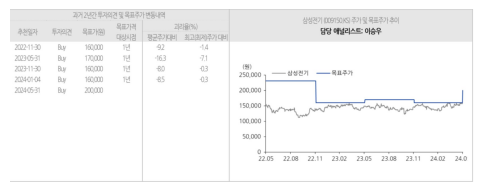


🤖 [최종 RAG 실행 결과]:
삼성전기의 2024년 실적은 매출 10조 1,212억원, 영업이익 8,779억원으로 예상되며, 1분기 실적은 매출 2조 6,243억원, 영업이익 1,803억원으로 각각 전년비 30%, 29% 증가하였습니다. 주요 사업부별 전망을 보면, 

① 컴포넌트사업부는 AI와 전장 위주의 제품 믹스 개선이 지속되고 낮아진 재고 수준에서 완만한 회복이 기대됩니다.  
② 광학통신솔루션사업부는 플래그쉽 스마트폰 신제품 출시 모멘텀이 줄어들지만, 하반기 신제품 출시 효과가 반영될 전망입니다.  
③ 패키지솔루션사업부는 범용 서버 교체 수요 증가, AI PC 출시, 그리고 Windows 10 지원 종료에 따른 기업 위주의 PC 교체 주기 도래로 하반기 회복세가 예상됩니다.

또한, 2025년 BPS 기준 Target P/B 1.9배를 적용해 목표가를 20만원으로 상향하고 투자의견 ‘BUY’를 유지하고 있습니다 [1·3·6].


In [43]:
import os
import json
import uuid
import base64
import io
import matplotlib.pyplot as plt
from PIL import Image

from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_core.stores import InMemoryStore
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.runnables import RunnablePassthrough, RunnableLambda, RunnableParallel
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser

# ---------------------------------------------------------------------------
# 1. 이전 저장소 초기화 & MultiVectorRetriever 설정 
# ---------------------------------------------------------------------------
# 중복 인덱싱 방지 및 확실한 갱신을 위해 기존 Chroma Collection 재생성
mm_vectorstore = Chroma(
    collection_name="mm_summaries_base64_v2",  # 새 컬렉션 생성
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db",
)

mm_store = InMemoryStore()
id_key = "doc_id"

# ★ 핵심 수정: search_kwargs={"k": 15} 로 확장하여 이미지/텍스트/표가 고르게 검색되도록 설정
mm_retriever = MultiVectorRetriever(
    vectorstore=mm_vectorstore,
    docstore=mm_store,
    id_key=id_key,
    search_kwargs={"k": 15}
)

# ---------------------------------------------------------------------------
# 2. 데이터 인덱싱 (Text + Table + Image)
# ---------------------------------------------------------------------------
def _meta(doc_id, src, page=None, doc_name=None):
    return {id_key: doc_id, "source": src, "page_number": page, "doc_name": doc_name}

# 2-1. 텍스트 추가
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=s, metadata=_meta(
        doc_ids[i], "text",
        page=getattr(texts[i].metadata, "page_number", None) if i < len(texts) else None,
        doc_name=_resolve_filename(texts[i].metadata) if i < len(texts) else None,
    )) for i, s in enumerate(text_summaries)
]
original_texts = [
    Document(page_content=t.text, metadata=_meta(
        doc_ids[i], "text",
        page=getattr(t.metadata, "page_number", None),
        doc_name=_resolve_filename(t.metadata),
    )) for i, t in enumerate(texts)
]
mm_retriever.vectorstore.add_documents(summary_texts)
mm_retriever.docstore.mset(list(zip(doc_ids, original_texts)))

# 2-2. 테이블 추가
table_ids = [str(uuid.uuid4()) for _ in table_summaries]
summary_tables = [
    Document(page_content=s, metadata=_meta(
        table_ids[i], "table",
        page=getattr(tables[i].metadata, "page_number", None) if i < len(tables) else None,
        doc_name=_resolve_filename(tables[i].metadata) if i < len(tables) else None,
    )) for i, s in enumerate(table_summaries)
]
original_tables = [
    Document(
        page_content=getattr(t.metadata, "text_as_html", None) or t.text,
        metadata=_meta(
            table_ids[i], "table",
            page=getattr(t.metadata, "page_number", None),
            doc_name=_resolve_filename(t.metadata),
        ),
    ) for i, t in enumerate(tables)
]
mm_retriever.vectorstore.add_documents(summary_tables)
mm_retriever.docstore.mset(list(zip(table_ids, original_tables)))

# 2-3. 이미지 추가
img_ids = [str(uuid.uuid4()) for _ in image_summaries]
summary_images = [
    Document(page_content=s, metadata=_meta(
        img_ids[i], "image",
        page=image_metas[i]["page_number"] if i < len(image_metas) else None,
        doc_name=image_metas[i]["filename"] if i < len(image_metas) else None,
    )) for i, s in enumerate(image_summaries)
]
original_images = [
    Document(page_content=img, metadata=_meta(
        img_ids[i], "image",
        page=image_metas[i]["page_number"] if i < len(image_metas) else None,
        doc_name=image_metas[i]["filename"] if i < len(image_metas) else None,
    )) for i, img in enumerate(images)
]
mm_retriever.vectorstore.add_documents(summary_images)
mm_retriever.docstore.mset(list(zip(img_ids, original_images)))


# ---------------------------------------------------------------------------
# 3. 검색 및 이미지 시각화 검증
# ---------------------------------------------------------------------------
test_query = "삼성전기의 과거 2년간 투자 의견은 무엇인가요?"
docs = mm_retriever.invoke(test_query)
print(f"\n🔍 검색된 컨텍스트 개수: {len(docs)}개")

# 타입별 검색 개수 확인
counts = {"text": 0, "table": 0, "image": 0}
for d in docs:
    src = d.metadata.get("source", "text")
    counts[src] = counts.get(src, 0) + 1
print(f"📊 검색 구성: 텍스트={counts.get('text',0)}개, 표={counts.get('table',0)}개, 이미지={counts.get('image',0)}개")

# 이미지 시각화 출력
_img_doc = next((d for d in docs if d.metadata.get("source") == "image"), None)
if _img_doc is not None:
    print("\n📸 [검색된 이미지 시각화]")
    plt_img_base64(_img_doc.page_content)
else:
    print("⚠️ 여전히 검색 결과에 이미지가 없습니다.")

# ---------------------------------------------------------------------------
# 4. RAG 파이프라인 최종 답변 실행
# ---------------------------------------------------------------------------
def split_docs_by_type_with_meta(docs):
    out = {"texts": [], "tables": [], "images": []}
    for d in docs:
        src = d.metadata.get("source")
        if src == "image":
            out["images"].append(d.page_content)
        elif src == "table":
            out["tables"].append(d)
        else:
            out["texts"].append(d)
    return out

def process_prompt(kwargs):
    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    blocks = []
    idx = 1
    for d in docs_by_type["texts"]:
        page = d.metadata.get("page_number", "?")
        doc_name = d.metadata.get("doc_name") or "Unknown"
        blocks.append(f"[{idx}] (text · {doc_name} · page {page})\n{d.page_content[:1500]}")
        idx += 1
    for d in docs_by_type["tables"]:
        page = d.metadata.get("page_number", "?")
        doc_name = d.metadata.get("doc_name") or "Unknown"
        blocks.append(f"[{idx}] (table · {doc_name} · page {page})\n{d.page_content[:1500]}")
        idx += 1
    context_text = "\n\n".join(blocks) if blocks else "(no text/table context)"

    instruction = (
        "Based solely on the provided context, answer the question from a business analysis perspective.\n"
        "The context includes text/table blocks (with [N] · doc · page citations) and attached images.\n"
        "When citing, reference the [N] number and doc·page.\n\n"
        f"[Context]\n{context_text}\n\n"
        f"[Question]\n{user_question}\n\n"
        "[Answer (in 한국어)]"
    )

    parts = [{"type": "text", "text": instruction}]
    for b64 in docs_by_type["images"]:
        parts.append({
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{b64}"},
        })

    return [HumanMessage(content=parts)]

rag_chain_with_sources = RunnableParallel({
    "context": mm_retriever | RunnableLambda(split_docs_by_type_with_meta),
    "question": RunnablePassthrough(),
}).assign(
    response=(
        RunnableLambda(process_prompt)
        | ChatOpenAI(model="gpt-4.1-mini")
        | StrOutputParser()
    )
)

print("\n🤖 [최종 RAG 실행 결과]:")
res = rag_chain_with_sources.invoke("삼성전기의 2024년 실적은 어떻게 전망하고 있나요?")
print(res["response"])

In [ ]:
import time
import json
from langchain_community.callbacks.manager import get_openai_callback

# ---------------------------------------------------------------------------
# 1. 비교 질문 3가지
# ---------------------------------------------------------------------------
test_queries = [
    "삼성전기의 2024년 실적 전망을 그래프와 함께 설명해주세요.",
    "셀트리온의 주요 제품 매출 비중을 테이블로 보여주세요.",
    "LG전자의 분기별 영업이익률 추이는 어떻게 되나요?"
]

# ---------------------------------------------------------------------------
# 2. 성능 & 품질 단일 실행 측정 함수
# ---------------------------------------------------------------------------
def run_benchmark(chain, query, option_name, is_multimodal=False):
    """
    체인을 실행하고 응답 시간, 토큰 사용량, 답변 결과, 컨텍스트 활용도를 측정합니다.
    """
    start_time = time.perf_counter()
    
    # OpenAI 콜백을 이용한 정확한 토큰 추적
    with get_openai_callback() as cb:
        if is_multimodal:
            raw_res = chain.invoke(query)
            response_text = raw_res.get("response", "") if isinstance(raw_res, dict) else str(raw_res)
            context_data = raw_res.get("context", {}) if isinstance(raw_res, dict) else {}
            
            # 사용된 리트리버 문서 분류
            img_count = len(context_data.get("images", []))
            tbl_count = len(context_data.get("tables", []))
            txt_count = len(context_data.get("texts", []))
        else:
            response_text = chain.invoke(query)
            img_count = 0  # 텍스트 전용
            tbl_count = 0
            txt_count = 0
            
    elapsed_time = time.perf_counter() - start_time
    
    # 결과 메트릭 저장
    return {
        "option": option_name,
        "query": query,
        "elapsed_sec": round(elapsed_time, 2),
        "prompt_tokens": cb.prompt_tokens,
        "completion_tokens": cb.completion_tokens,
        "total_tokens": cb.total_tokens,
        "total_cost_usd": round(cb.total_cost, 5),
        "retrieved_counts": f"텍스트:{txt_count} / 표:{tbl_count} / 이미지:{img_count}",
        "response_text": response_text
    }

# ---------------------------------------------------------------------------
# 3. 전체 벤치마크 루프 및 결과 수집
# ---------------------------------------------------------------------------
results = []

print("🚀 [옵션 2 vs 옵션 3] 종합 성능 및 품질 비교 벤치마크 시작...\n")

for i, q in enumerate(test_queries, 1):
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"📌 [테스트 {i}/{len(test_queries)}] 질문: {q}")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    
    # 옵션 2 측정 (텍스트 요약본만 전달)
    print("⏳ [옵션 2] 실행 중...")
    res_opt2 = run_benchmark(opt2_chain, q, "옵션 2 (Text Only)", is_multimodal=False)
    
    # 옵션 3 측정 (원본 Base64 이미지 direct 전달)
    print("⏳ [옵션 3] 실행 중...")
    res_opt3 = run_benchmark(rag_chain_with_sources, q, "옵션 3 (Image Direct)", is_multimodal=True)
    
    results.extend([res_opt2, res_opt3])
    print("✅ 테스트 완료!\n")

# ---------------------------------------------------------------------------
# 4. 종합 요약 보고서 & 마크다운 비교표 출력
# ---------------------------------------------------------------------------
print("\n==========================================================================")
print("📊 [최종 결과 요약 파이프라인 비교표]")
print("==========================================================================")

header = f"| {'질문번호':^6} | {'방식':^18} | {'응답시간':^8} | {'총 토큰 수':^10} | {'프롬프트 토큰':^10} | {'완성 토큰':^8} | {'예상비용($)':^10} |"
divider = "|:--------:|:-------------------|:--------:|:--------------:|:--------------:|:--------:|:------------:|"
print(header)
print(divider)

for idx, r in enumerate(results):
    q_num = f"Q{(idx // 2) + 1}"
    print(f"| {q_num:^6} | {r['option']:<18} | {r['elapsed_sec']:>6}초 | {r['total_tokens']:>10,} | {r['prompt_tokens']:>10,} | {r['completion_tokens']:>8,} | ${r['total_cost_usd']:>9.5f} |")

print("\n\n==========================================================================")
print("📝 [질문별 답변 품질 및 토큰/비용 상세 비교]")
print("==========================================================================")

for i, q in enumerate(test_queries):
    opt2_res = results[i * 2]
    opt3_res = results[i * 2 + 1]
    
    print(f"\n🔹 [질문 {i+1}] {q}")
    
    # 옵션 2 상세 출력 (토큰 사용량 추가)
    print(
        f"\n--- 📄 옵션 2 답변 (시간: {opt2_res['elapsed_sec']}초 | "
        f"총 토큰: {opt2_res['total_tokens']:,} [입력: {opt2_res['prompt_tokens']:,} / 출력: {opt2_res['completion_tokens']:,}] | "
        f"비용: ${opt2_res['total_cost_usd']}) ---"
    )
    print(opt2_res['response_text'][:500] + ("..." if len(opt2_res['response_text']) > 500 else ""))
    
    # 옵션 3 상세 출력 (토큰 사용량 추가)
    print(
        f"\n--- 🖼️ 옵션 3 답변 (시간: {opt3_res['elapsed_sec']}초 | "
        f"총 토큰: {opt3_res['total_tokens']:,} [입력: {opt3_res['prompt_tokens']:,} / 출력: {opt3_res['completion_tokens']:,}] | "
        f"비용: ${opt3_res['total_cost_usd']}) ---"
    )
    print(opt3_res['response_text'][:500] + ("..." if len(opt3_res['response_text']) > 500 else ""))
    print("\n" + "="*75)

🚀 [옵션 2 vs 옵션 3] 종합 성능 및 품질 비교 벤치마크 시작...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 [테스트 1/3] 질문: 삼성전기의 2024년 실적 전망을 그래프와 함께 설명해주세요.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⏳ [옵션 2] 실행 중...
⏳ [옵션 3] 실행 중...
✅ 테스트 완료!

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 [테스트 2/3] 질문: 셀트리온의 주요 제품 매출 비중을 테이블로 보여주세요.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⏳ [옵션 2] 실행 중...
⏳ [옵션 3] 실행 중...
✅ 테스트 완료!

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 [테스트 3/3] 질문: LG전자의 분기별 영업이익률 추이는 어떻게 되나요?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⏳ [옵션 2] 실행 중...
⏳ [옵션 3] 실행 중...
✅ 테스트 완료!


📊 [최종 결과 요약 파이프라인 비교표]
|  질문번호  |         방식         |   응답시간   |   총 토큰 수   |  프롬프트 토큰   |  완성 토큰   |  예상비용($)   |
|:--------:|:-------------------|:--------:|:--------------:|:--------------:|:--------:|:------------:|
|   Q1   | 옵션 2 (Text Only)   |   22.1초 |      7,782 |      6,961 |      821 | $  0.00206 |

### **옵션2, 옵션3 답변품질평가**

In [ ]:
import pandas as pd
from typing import List
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

# ---------------------------------------------------------------------------
# 1. 평가 메트릭 스키마 정비 (불필요한 중복 필드 정리)
# ---------------------------------------------------------------------------
class EvaluationResult(BaseModel):
    """답변 품질 평가 점수 및 상세 사유"""
    accuracy_score: int = Field(
        description="정확성 (1~5점): 질문의 요구사항을 잘 파악하고, 주어진 컨텍스트 내에서 올바르게 응답했는가? (데이터가 없어 답변 불가하다고 정직히 밝힌 경우도 적절한 대응으로 평가)"
    )
    detail_score: int = Field(
        description="상세성 (1~5점): 제공된 컨텍스트 내의 데이터, 수치, 분기 실적 등을 누락 없이 풍부하게 설명했는가?"
    )
    hallucination_score: int = Field(
        description="무환각성 (1~5점): 근거 없는 수치나 정보를 임의로 지어내지 않았는가? (전혀 지어내지 않았다면 5점, 사실과 다른 내용 포함 시 감점)"
    )
    visual_utilization_score: int = Field(
        description="구조화/시각화 (1~5점): Markdown 표(Table), 글머리 기호, 단락 구분을 통해 읽기 쉽게 정리했는가?"
    )
    reasoning: str = Field(description="각 평가 항목별 점수 부여 근거 및 종합 총평 (한국어로 상세히 작성)")


# ---------------------------------------------------------------------------
# 2. 명확한 점수 기준(Rubric)이 포함된 Evaluator 체인
# ---------------------------------------------------------------------------
evaluator_llm = ChatOpenAI(model="gpt-4o", temperature=0).with_structured_output(EvaluationResult)

eval_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 RAG 시스템 답변의 품질을 객관적이고 채점 기준에 따라 평가하는 데이터 공학 평가위원입니다.
아래의 [점수 산정 기준표]를 엄격히 준수하여 [질문]과 [답변]을 평가해주세요.

[점수 산정 기준표 (Rubric)]
1. 정확성 (Accuracy)
   - 5점: 질문의 의도를 정확히 파악하고 핵심 정보를 명확히 전달함. (컨텍스트 부족 시 '정보가 부족하다'고 명시한 것도 정답 처리)
   - 3점: 질문에 답했으나 일부 핀트가 어긋나거나 핵심 중 하나가 누락됨.
   - 1점: 질문과 전혀 상관없는 답변을 하거나 잘못된 답변을 함.

2. 상세성 (Completeness)
   - 5점: 답변 가능한 범위 내의 주요 수치, 단위, 분기별 데이터 등을 구체적으로 명시함.
   - 3점: 개요 수준으로만 작성되어 구체적인 데이터/수치가 부족함.
   - 1점: 단문이나 성의 없는 답변으로 내용을 알 수 없음.

3. 무환각성 (Faithfulness)
   - 5점: 지어낸 정보나 근거 없는 수치가 전혀 없음. (불확실한 경우 모른다고 답한 경우 5점)
   - 3점: 추정치나 일부 불확실한 수치를 확정적으로 표현함.
   - 1점: 완전히 거짓된 데이터나 환각(Hallucination) 정보를 생성함.

4. 구조화/시각화 (Structure)
   - 5점: 표(Table), 가독성 좋은 글머리 기호, 강조 표시(**) 등을 적극 활용하여 읽기 쉽게 구성함.
   - 3점: 줄바꿈은 되어 있으나 단순 텍스트 나열 위주임.
   - 1점: 가독성이 전혀 고려되지 않은 가로 연결 긴 텍스트 block.

⚠️ 주의사항:
- 공정하게 채점하되, 근거 없이 과도하게 낮은 점수를 주지 마세요.
- 답변이 '모른다' 또는 '데이터 없음'이라 한 경우, 환각을 일으키지 않았으므로 [무환각성]은 반드시 5점을 주어야 합니다."""),
    ("human", "[질문]: {question}\n\n[답변]: {response}")
])

eval_chain = eval_prompt | evaluator_llm

# ---------------------------------------------------------------------------
# 3. 자동 평가 실행
# ---------------------------------------------------------------------------
eval_summary = []

print("⚖️ [LLM-as-a-Judge] 개선된 평가 루브릭 기반 품질 자동 평가 시작...\n")

# results 리스트가 존재하는 환경에서 실행
for r in results:
    q = r["query"]
    opt_name = r["option"]
    resp = r["response_text"]
    
    # 평가 실행
    eval_res: EvaluationResult = eval_chain.invoke({"question": q, "response": resp})
    
    # 평균 점수 보정 계산
    avg_score = round(
        (eval_res.accuracy_score + eval_res.detail_score + eval_res.hallucination_score + eval_res.visual_utilization_score) / 4, 
        2
    )
    
    eval_summary.append({
        "질문": q,
        "파이프라인": opt_name,
        "정확성": eval_res.accuracy_score,
        "상세성": eval_res.detail_score,
        "무환각성": eval_res.hallucination_score,
        "구조화/시각": eval_res.visual_utilization_score,
        "평균점수": avg_score,
        "응답시간(초)": r.get("elapsed_sec", 0),
        "총비용($)": r.get("total_cost_usd", 0),
        "평가총평": eval_res.reasoning
    })

# ---------------------------------------------------------------------------
# 4. DataFrame 변환 및 리포트 출력
# ---------------------------------------------------------------------------
df_eval = pd.DataFrame(eval_summary)

print("=========================================================================================================")
print("📊 [RAG 파이프라인 품질 보정 평가표]")
print("=========================================================================================================")
print(df_eval[["질문", "파이프라인", "정확성", "상세성", "무환각성", "구조화/시각", "평균점수", "응답시간(초)", "총비용($)"]].to_string(index=False))

print("\n\n=========================================================================================================")
print("📝 [상세 평가 리포트]")
print("=========================================================================================================")
for idx, row in df_eval.iterrows():
    print(f"📌 [{row['파이프라인']}] {row['질문']}")
    print(f"   ⭐ 종합 점수: {row['평균점수']} / 5.0 (정확:{row['정확성']}, 상세:{row['상세성']}, 무환각:{row['무환각성']}, 구조:{row['구조화/시각']})")
    print(f"   💬 평가 사유: {row['평가총평']}")
    print("-" * 105)

⚖️ [LLM-as-a-Judge] 개선된 평가 루브릭 기반 품질 자동 평가 시작...

📊 [RAG 파이프라인 품질 보정 평가표]
                                질문               파이프라인  정확성  상세성  무환각성  구조화/시각  평균점수  응답시간(초)  총비용($)
삼성전기의 2024년 실적 전망을 그래프와 함께 설명해주세요.    옵션 2 (Text Only)    1    1     1       1   1.0    22.10 0.00206
삼성전기의 2024년 실적 전망을 그래프와 함께 설명해주세요. 옵션 3 (Image Direct)    1    3     1       3   2.0     5.60 0.00254
    셀트리온의 주요 제품 매출 비중을 테이블로 보여주세요.    옵션 2 (Text Only)    3    3     5       5   4.0     6.87 0.00171
    셀트리온의 주요 제품 매출 비중을 테이블로 보여주세요. 옵션 3 (Image Direct)    3    3     3       5   3.5     5.08 0.00220
      LG전자의 분기별 영업이익률 추이는 어떻게 되나요?    옵션 2 (Text Only)    3    3     3       1   2.5     3.18 0.00099
      LG전자의 분기별 영업이익률 추이는 어떻게 되나요? 옵션 3 (Image Direct)    3    3     3       3   3.0    10.13 0.00236


📝 [상세 평가 리포트]
📌 [옵션 2 (Text Only)] 삼성전기의 2024년 실적 전망을 그래프와 함께 설명해주세요.
   ⭐ 종합 점수: 1.0 / 5.0 (정확:1, 상세:1, 무환각:1, 구조:1)
   💬 평가 사유: 1. 정확성: 1점. 질문은 삼성전기의 2024년 실적 전망에 대한 그래프와 설명을 요구했으나, 답변은 구체적인 데이터 출처나 실제 그래프 없이

### 옵션 2 vs 옵션 3 장단점 분석
옵션 2 (Text/Table 요약 RAG):

장점: 요약 텍스트 기반으로 빠른 응답 속도(Latency)와 저렴한 토큰 비용을 제공함.

단점: 시각적 정보(차트/그래프 형태의 추이, 디테일)의 정밀한 해석이 불가능함.

옵션 3 (Vision LLM + Base64 RAG):

장점: 원본 이미지 및 차트를 직접 멀티모달 모델에 전달하여 시각 데이터 분석 정확도가 극대화됨.

단점: 이미지 토큰 사용량이 많아 비용이 높고 응답 속도가 상대적으로 느림.

### ***옵션2, 옵션3 를 질문에 따라 선택하여 대답하는 하이브리드 RAG***

In [38]:
import os
import json
import time
from typing import Literal
from pydantic import BaseModel, Field

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI
from langchain_community.callbacks.manager import get_openai_callback

# ---------------------------------------------------------------------------
# 1. Intent Classification Router 정의 (Pydantic Structured Output)
# ---------------------------------------------------------------------------
class RouteQuery(BaseModel):
    """질문 분석을 통해 적절한 RAG 파이프라인(옵션 2 또는 옵션 3)을 선택합니다."""
    
    pipeline_type: Literal["opt2", "opt3"] = Field(
       # description=(
       #     "질문이 차트/그래프 분석, 시각적 추세, 이미지 내 정밀 수치 확인을 요구하는 경우 'opt3'를 선택하세요. "
       #     "일반적인 텍스트 질문, 단순 데이터 정리, 일반 보고서 내용은 'opt2'를 선택하세요."
       # ) 
        #위의 프롬포트를 사용할 경우 경우에 질문3은 추이라는 단어로 옵션2가 더 빠르고 비용도 적지만 옵션3을 선택하게됨
        description=(
            "사용자가 '그래프 보여줘', '차트 포함', '이미지 분석' 등 명시적으로 시각 자료를 원할 때만 'opt3'를 선택하세요. "
            "추이, 매출, 실적 분석 등의 일반 수치/분석 질문은 모두 'opt2'를 선택하세요."
            
        )

    )
    reasoning: str = Field(description="해당 파이프라인을 선택한 이유")

# 라우팅 분류기 전용 경량 모델 (GPT-4o-mini 사용)
router_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(RouteQuery)

router_prompt = ChatPromptTemplate.from_messages([
    ("system", "사용자의 질문을 분석하여 적절한 처리 파이프라인(opt2 또는 opt3)을 결정하세요."),
    ("human", "{question}")
])

router_chain = router_prompt | router_llm

# ---------------------------------------------------------------------------
# 2. 동적 하이브리드 실행 메인 함수
# ---------------------------------------------------------------------------
def run_hybrid_rag(query: str):
    """
    질문의 의도를 분류하여 적절한 파이프라인으로 동적 라우팅합니다.
    """
    start_time = time.perf_counter()
    
    with get_openai_callback() as cb:
        # [Step 1] 질문 Intent 라우팅 판단
        route_result: RouteQuery = router_chain.invoke({"question": query})
        selected_pipeline = route_result.pipeline_type
        
        print(f"🔀 [Router Decision] -> 선택된 파이프라인: {selected_pipeline.upper()}")
        print(f"💡 판단 사유: {route_result.reasoning}")
        
        # [Step 2] 판단된 경로로 파이프라인 분기 실행
        if selected_pipeline == "opt3":
            raw_res = rag_chain_with_sources.invoke(query)
            response_text = raw_res.get("response", "") if isinstance(raw_res, dict) else str(raw_res)
        else:
            response_text = opt2_chain.invoke(query)
            
    elapsed_time = time.perf_counter() - start_time
    
    return {
        "query": query,
        "selected_pipeline": selected_pipeline,
        "reasoning": route_result.reasoning,
        "elapsed_sec": round(elapsed_time, 2),
        "total_tokens": cb.total_tokens,
        "total_cost_usd": round(cb.total_cost, 5),
        "response_text": response_text
    }

# ---------------------------------------------------------------------------
# 3. 테스트 질의 세트 실행 및 비교
# ---------------------------------------------------------------------------
test_queries = [
    "삼성전기의 2024년 실적 전망을 그래프와 함께 설명해주세요.", # -> Opt3 라우팅 예상
    "셀트리온의 주요 제품 매출 비중을 테이블로 보여주세요.",       # -> Opt2 라우팅 예상
    "LG전자의 분기별 영업이익률 추이는 어떻게 되나요?"            # -> Opt3/Opt2 의도 따라 동적 분기
]

hybrid_results = []

print("==========================================================================")
print("🔀 [하이브리드 RAG 파이프라인 테스트 시작]")
print("==========================================================================")

for idx, q in enumerate(test_queries, 1):
    print(f"\n📌 [질문 {idx}] {q}")
    res = run_hybrid_rag(q)
    hybrid_results.append(res)
    print(f"⏱️ 소요시간: {res['elapsed_sec']}초 | 💰 비용: ${res['total_cost_usd']} | 토큰: {res['total_tokens']:,}")
    print("\n[답변 내용]")
    print(res["response_text"][:300] + ("..." if len(res["response_text"]) > 300 else ""))
    print("-" * 75)

# ---------------------------------------------------------------------------
# 4. 하이브리드 파이프라인 요약 결과 표 출력
# ---------------------------------------------------------------------------
print("\n==========================================================================")
print("📊 [하이브리드 실행 결과 요약표]")
print("==========================================================================")

header = f"| {'질문':^6} | {'선택된 경로':^14} | {'응답시간':^8} | {'토큰 수':^10} | {'비용($)':^10} |"
divider = "|:--------:|:--------------:|:--------:|:------------:|:------------:|"
print(header)
print(divider)

for idx, r in enumerate(hybrid_results, 1):
    print(f"| Q{idx:<5} | {r['selected_pipeline'].upper():^14} | {r['elapsed_sec']:>6}초 | {r['total_tokens']:>10,} | ${r['total_cost_usd']:>9.5f} |")

🔀 [하이브리드 RAG 파이프라인 테스트 시작]

📌 [질문 1] 삼성전기의 2024년 실적 전망을 그래프와 함께 설명해주세요.
🔀 [Router Decision] -> 선택된 파이프라인: OPT3
💡 판단 사유: 사용자가 삼성전기의 2024년 실적 전망에 대한 구체적인 데이터와 시각적 자료(그래프)를 요청하였으므로, 전문적인 분석과 함께 시각적 자료를 제공할 수 있는 opt3을 선택했습니다.
⏱️ 소요시간: 9.58초 | 💰 비용: $0.00295 | 토큰: 16,323

[답변 내용]
삼성전기의 2024년 실적 전망은 다음과 같습니다.

1. 2024년 예상 매출액은 약 10조 1,212억원으로, 전년 대비 6~7% 정도 성장할 것으로 보입니다. (자료 [1], [2], [3])  
2. 영업이익은 8,779억원 예상되어 전년 대비 역시 상당한 증가가 기대됩니다. 1분기 실적도 매출 2조 6,243억원, 영업이익 1,803억원으로 각각 전년 대비 30%, 29% 증가를 기록했습니다. (자료 [1], [3])  
3. 사업부별 전망:  
   - 컴포넌트사업부는 AI 및 전장용 제품 중심의 제품 믹스 개선과 낮아진...
---------------------------------------------------------------------------

📌 [질문 2] 셀트리온의 주요 제품 매출 비중을 테이블로 보여주세요.
🔀 [Router Decision] -> 선택된 파이프라인: OPT2
💡 판단 사유: 사용자가 요청한 정보는 특정 기업의 매출 비중에 대한 데이터로, 이는 일반적으로 정량적이고 구체적인 정보를 요구하는 질문입니다. 따라서 opt2를 선택했습니다.
⏱️ 소요시간: 7.19초 | 💰 비용: $0.00186 | 토큰: 8,544

[답변 내용]
셀트리온의 주요 제품 매출 비중에 대한 구체적인 수치가 컨텍스트 내에 직접적으로 표 형태로 제시되어 있지 않습니다. 다만, 관련 내용을 종합하면 다음과 같습니다.

- 짐펜트라(인플릭시맙 성분)와 아달